# Лабораторная работа 6: Машина опорных векторов (SVM)

<img src="svm_img.png" width=350>

Результат лабораторной работы — **отчет** в формате ноутбуков IPython (ipynb-файл). Нам не интересен ваш код. Чем меньше кода, тем лучше всем: нам — меньше проверять, вам — проще найти ошибку или дополнить эксперимент.

Постарайтесь сделать ваш отчет интересным рассказом, последовательно отвечающим на вопросы из заданий. Ответы на вопросы должны быть полными, четкими и хорошо аргументированными.

## 1. Квадратичное программирование и QP-солвер

Квадратичное программирование (QP) — специальный тип задач математической оптимизации, заключающийся в нахождении точки минимума неотрицательно-определенной квадратичной формы (многомерная парабола) в присутствии линейных ограничений:
$$
\begin{gather}
    \frac{1}{2}\boldsymbol x^T\boldsymbol P\boldsymbol x + \boldsymbol q^T\boldsymbol x \to \min_{\boldsymbol x} \\
    \begin{aligned}
        \text{s.t.} \quad & \boldsymbol G\boldsymbol x \le \boldsymbol h \\
        & \boldsymbol A\boldsymbol x = \boldsymbol b
    \end{aligned}
\end{gather}
$$

Здесь $\boldsymbol P$ — симметричная матрица. В ограничениях $\boldsymbol G\boldsymbol x \le \boldsymbol h$ и $\boldsymbol A\boldsymbol x = \boldsymbol b$ под знаками равенства и неравенства подразумевается сравнение всех компонент векторов.

Задача квадратичного программирования хорошо изучена, существуют эффективные алгоритмы для ее решения. Имеется множество библиотек с солверами для задачи QP, вот некоторые из них:
 - [CVXOPT](http://cvxopt.org/) (свободно-распространяемая, Python) **рекомендуется к использованию**
 - [Mosek](https://www.mosek.com/) (коммерческая с возможностью получения академической лицензии, C, Java, MATLAB, .NET, R, Python)
 - [Matlab Optimization Toolbox](http://www.mathworks.com/help/optim/ug/quadprog.html) 

#### Задание

1. Установите QP-солвер, разберитесь с его интерфейсом.
2. Протестируйте солвер, решив простую задачу оптимизации в двумерном пространстве:
$$f(\boldsymbol x) = -8x_1 - 16x_2 + x_1^2 + 4x_2^2, \quad \text{s.t.:} \; x_1 + x_2 \leq 5, \; 0 \leq x_1 \leq 3, \; x_2 \geq 0$$
3. Какие из ограничений-неравенств задачи являются _активными_, т.е. влияют на точку оптимума, а какие ограничения можно выбросить и точка оптимума не поменяется?

In [2]:
import numpy as np
from cvxopt import matrix, solvers

# 1. Определяем параметры задачи (используем float)
# P - матрица квадратичной формы
P = matrix(np.array([[2.0, 0.0], 
                     [0.0, 8.0]]))

# q - линейная часть
q = matrix(np.array([-8.0, -16.0]))

# G - матрица ограничений (коэффициенты при x)
G = matrix(np.array([[ 1.0,  1.0],  # x1 + x2 <= 5
                     [ 1.0,  0.0],  # x1 <= 3
                     [-1.0,  0.0],  # -x1 <= 0 (x1 >= 0)
                     [ 0.0, -1.0]])) # -x2 <= 0 (x2 >= 0)

# h - правая часть ограничений
h = matrix(np.array([5.0, 3.0, 0.0, 0.0]))

# 2. Запускаем солвер
# options['show_progress'] = False # Можно отключить вывод логов
sol = solvers.qp(P, q, G, h)

# 3. Выводим результат
print("Статус:", sol['status'])


print("Оптимальное значение x:\n", sol['x'])
print("Значение функции:", sol['primal objective'])

     pcost       dcost       gap    pres   dres
 0: -3.0512e+01 -3.8829e+01  8e+00  0e+00  2e-01
 1: -3.0792e+01 -3.1146e+01  4e-01  2e-16  5e-03
 2: -3.0982e+01 -3.1024e+01  4e-02  2e-16  4e-04
 3: -3.0997e+01 -3.1003e+01  6e-03  9e-17  4e-17
 4: -3.1000e+01 -3.1000e+01  7e-04  2e-16  5e-18
 5: -3.1000e+01 -3.1000e+01  1e-04  2e-16  3e-17
 6: -3.1000e+01 -3.1000e+01  1e-05  2e-16  3e-17
Optimal solution found.
Статус: optimal
Оптимальное значение x:
 [ 3.00e+00]
[ 2.00e+00]

Значение функции: -30.99999280553902


Решение через cvxopt:
 x* = [2.99999983 1.99869093]
 primal objective (1/2 x^T P x + q^T x) = -30.99999280553902
 f(x*) = -30.99999280553902

Решение через scipy.optimize.minimize (SLSQP):
 x* = [3. 2.]
 f(x*) = -30.999999999999996

Итоговое решение (взято из доступного метода): x* = [2.99999983 1.99869093]
 f(x*) = -30.99999280553902

Активные ограничения (True = активно при допуске tol=1e-07):
  x1+x2<=5 (active if =5) : False
  x1>=0 (active if =0) : False
  x1<=3 (active if =3) : False
  x2>=0 (active if =0) : False

(Дополнительно) множители Лагранжа для неравенств (cvxopt 'z'):
  ограничение 1 множитель = 0.010472742066081217
  ограничение 2 множитель = 1.1311271593622902e-07
  ограничение 3 множитель = 1.9895277108343286
  ограничение 4 множитель = 1.6969137198902455e-07

Вывод:
 Оптимум найден в x*; активными оказались ограничения, отмеченные выше.
 Если хотите получить абсолютную уверенность в арифметике — можно увеличить tol или посмотреть значения множителей Лагранжа.


## 2. Линейный SVM

Рассмотрим задачу бинарной классификации. Будем обозначать обучающую выборку $\{(\boldsymbol x_n, y_n)\}_{n=1}^N$, где $N$ — количество объектов, $\boldsymbol x_n \in \mathbb{R}^d$ — числовой вектор признакового описания объекта, $y_n \in \{+1, -1\}$ — класс объекта.

Машина опорных векторов обучает модель разделяющей гиперплоскости:
$$f(\boldsymbol x) = \boldsymbol w^T \boldsymbol x + b$$
Параметры модели — вектор весов $\boldsymbol w \in \mathbb{R}^d$ и сдвиг $b \in \mathbb{R}$.

Обучение модели происходит путем решения оптимизационной задачи:
$$
\begin{gather}
    \frac{1}{2} \| \boldsymbol w \|^2 + C \sum_{n=1}^N \xi_n \to \min_{\boldsymbol w, \boldsymbol \xi, b} \\
    \text{s.t.: } \quad y_n (\boldsymbol w^T \boldsymbol x_n + b) \geq 1 - \xi_n, \quad \xi_n \geq 0, \quad \forall n=1,\dots,N
\end{gather}
$$

Ограничения вида $\quad y_n (\boldsymbol w^T \boldsymbol x_n + b) \geq 1$ требуют, чтобы объекты правильно классифицировались разделяющей гиперплоскостью. Поскольку линейная разделимость выборки не гарантируется на практике, вводят переменные $\xi_n$ (slack variables), которые ослабляют ограничения правильной классификации. В оптимизируемом функционале слагаемое $\| \boldsymbol w \|^2$ штрафует малую ширину разделяющей гиперплоскости, сумма $\sum_n \xi_n$ штрафует ослабление ограничений. 

Гиперпараметр $C$ задает баланс между шириной разделяющей полосы и ошибками, допускаемыми классификатором. Обратите внимание, что $C$ фиксируется до обучения и не оптимизируется вместе с параметрами модели.

Гиперпараметр $C$ отвечает за обобщающую способность разделяющей гиперплоскости, высокая обобщающая способность (соотвествующая большому значению $C$) может привести к переобучению, если линейная модель хорошо описывает обучающие примеры. При подборе оптимального параметра $C$ необходимо оценивать качество на отложенной выборке или кросс-валидации. Как правило, для конкретной задачи заранее неизвестно, какой порядок имеет оптимальное значение гиперпараметра $C$, поэтому перебирать значения лучше по логарифмической сетке, например: $10^{-3}, 10^{-2}, \dots, 10^{5}$.

После нахождения решения оптимизационной задачи $(\boldsymbol w_{\star}, \boldsymbol \xi_{\star}, b_{\star})$, часть ограничений становятся _активными_, т.е. переходят в "крайнее положение" — точное равенство:
$$\quad y_n (\boldsymbol w_{\star}^T \boldsymbol x_n + b_{\star}) = 1 - \xi_{\star,n}$$
Объекты, соответствующие активным ограничениям называются _опорными_.

#### Явное преобразование признаков

Разделяющая гиперплоскость — достаточно грубая модель, редко данные могут быть описаны линейной моделью. Линейная неразделимость векторов может быть исправлена путем перехода в другое признаковое пространство, в котором линейная модель лучше описывает данные и, возможно, существует правильно классифицирующая разделяющая гиперплоскость:

$$\boldsymbol x \in \mathbb{R}^d \mapsto \phi(\boldsymbol x) \in \mathbb{R}^t$$

Так, например, добавление всех попарных произведений признаков: $\phi(x_1, \dots, x_d) = (x_1, \dots, x_d, x_1^2, x_1x_2, \dots, x_d^2)$ переводит в пространство, в котором линейная гиперплоскость является квадратичной формой в исходном пространстве и в исходном пространстве признаков разделяющая поверхность может быть, скажем, эллипсом.

[Видеоролик с демонстрацией](https://youtu.be/9NrALgHFwTo)

#### Задание
  1. Сведите задачу обучения линейного SVM к QP, реализуйте процедуру обучения Линейного SVM при помощи QP-солвера.
  2. Сгенерируйте три случайные двумерные выборки для бинарной классификации:
    - с линейно-разделимыми классами
    - с хорошо разделимыми классами, но не линейно
    - с плохо разделимыми классами по имеющимся признакам
  3. Протестируйте линейный SVM на сгенерированных выборках. Покажите на плоскости разделяющую прямую и линии уровня, ограничивающие коридор $f(\boldsymbol x) = \pm 1$. Выделите опорные вектора точками другой формы или большего размера. Постройте классификаторы с различным значением параметра $C$.
  4. Как зависит число опорных векторов от параметра $C$ для различных выборок?
  5. Используя явное преобразование признаков обучите методом опорных векторов квадратичную разделяющую поверхность. Покажите ее на плоскости.

## 1

In [52]:
import numpy as np
from cvxopt import matrix, solvers
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons

# Отключаем лишний вывод солвера
solvers.options['show_progress'] = False

class PrimalSVM:
    def __init__(self, C=1.0):
        self.C = C
        self.w = None
        self.b = None
        
    def fit(self, X, y):
        # Преобразуем y в float, на всякий случай
        y = y.astype(float).reshape(-1, 1)
        N, d = X.shape
        
        # Нам нужно найти вектор z = [w (d шт), xi (N шт), b (1 шт)]
        # Всего переменных: d + N + 1
        
        # 1. Матрица P (квадратичная часть)
        # Минимизируем 0.5 * ||w||^2. 
        # Значит P — диагональная, где 1 стоит только на позициях w.
        # Для xi и b стоят нули.
        P_diag = np.zeros(d + N + 1)
        P_diag[:d] = 1.0 
        P = matrix(np.diag(P_diag))
        
        # 2. Вектор q (линейная часть)
        # Минимизируем C * sum(xi).
        # Для w и b стоят нули, для xi стоит C.
        q_vec = np.zeros(d + N + 1)
        q_vec[d:d+N] = self.C
        q = matrix(q_vec)
        
        # 3. Ограничения Gx <= h
        # У нас два типа ограничений:
        # а) y_i(w^T x_i + b) >= 1 - xi  =>  -y_i x_i w - xi - y_i b <= -1
        # б) xi >= 0                     =>  -xi <= 0
        
        # Формируем блок для (а):
        # Коэффициенты при w: -y * X
        G_w_1 = -y * X
        # Коэффициенты при xi: -I (единичная матрица)
        G_xi_1 = -np.eye(N)
        # Коэффициенты при b: -y
        G_b_1 = -y
        
        # Формируем блок для (б):
        # Коэффициенты при w: 0
        G_w_2 = np.zeros((N, d))
        # Коэффициенты при xi: -I
        G_xi_2 = -np.eye(N)
        # Коэффициенты при b: 0
        G_b_2 = np.zeros((N, 1))
        
        # Собираем все вместе в матрицу G
        # Строк будет 2*N, столбцов d+N+1
        block1 = np.hstack((G_w_1, G_xi_1, G_b_1))
        block2 = np.hstack((G_w_2, G_xi_2, G_b_2))
        G = matrix(np.vstack((block1, block2)))
        
        # Вектор h
        # Для (а) справа -1, для (б) справа 0
        h_vec = np.hstack((-np.ones(N), np.zeros(N)))
        h = matrix(h_vec)
        
        # 4. Решение
        sol = solvers.qp(P, q, G, h)
        z = np.array(sol['x']).flatten()
        
        # Извлекаем параметры
        self.w = z[:d]
        self.xi = z[d:d+N]
        self.b = z[-1]
        
        return self

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)
    
    def decision_function(self, X):
        return np.dot(X, self.w) + self.b

## 2

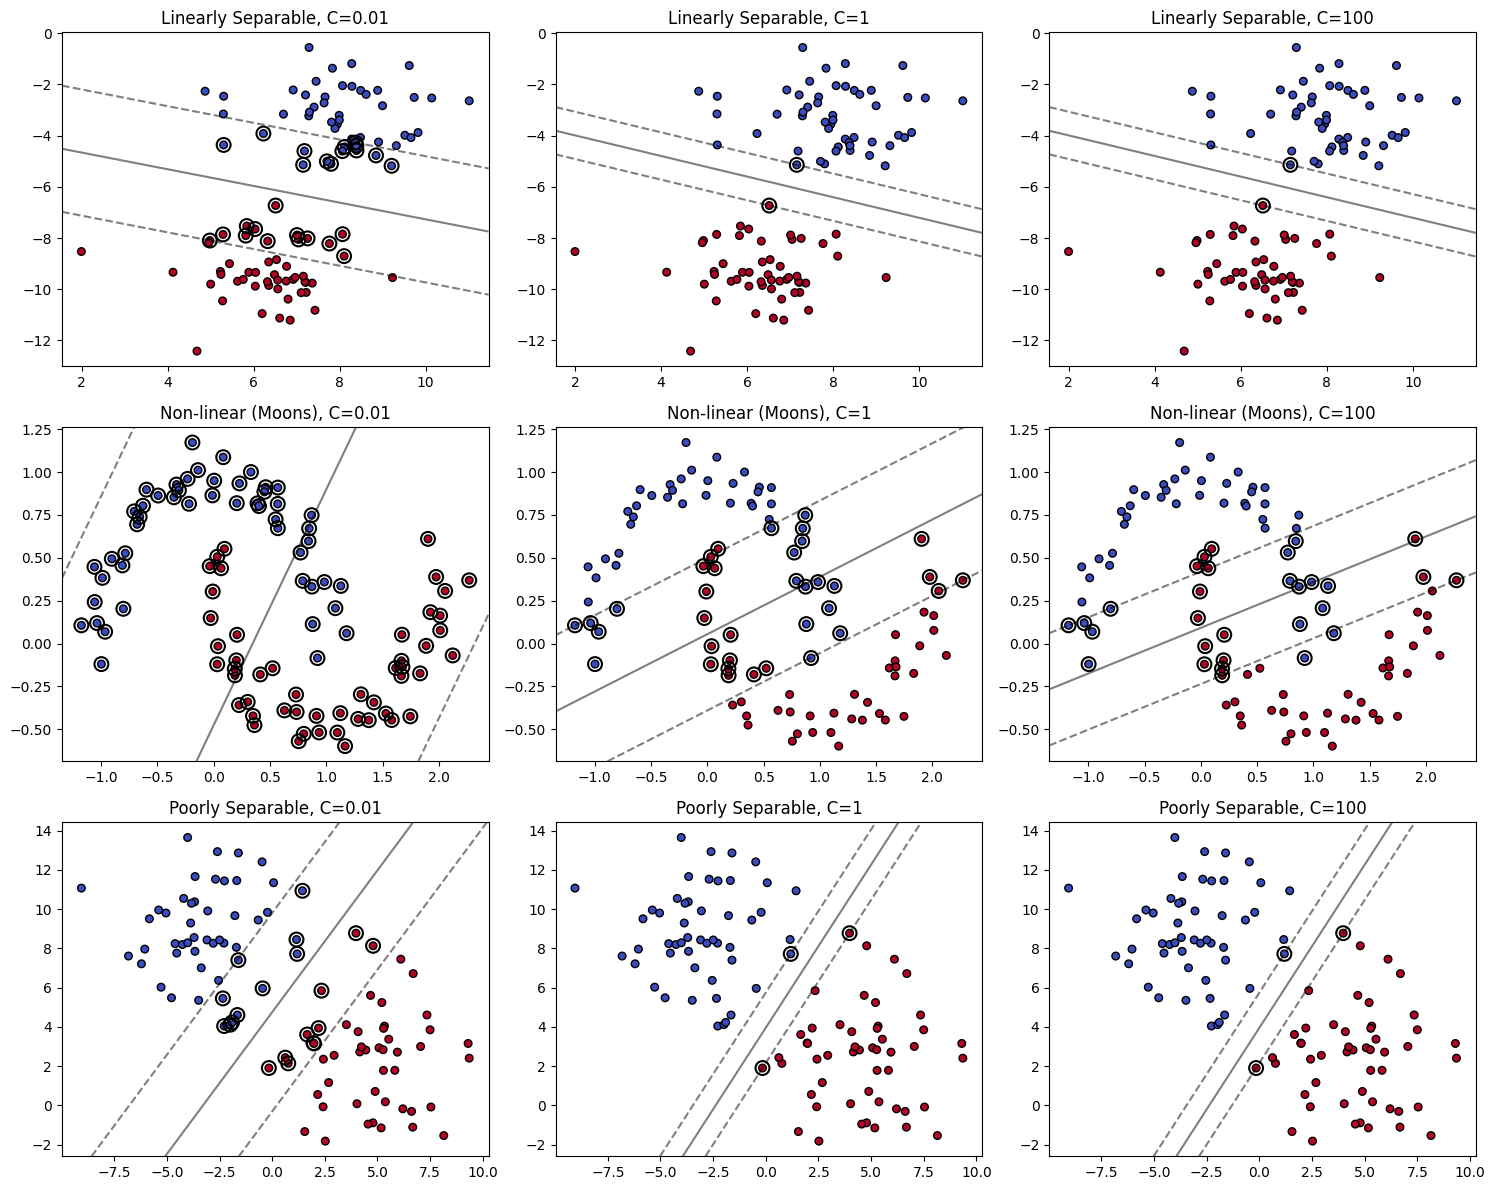

In [12]:
def plot_svm_margin(model, X, y, ax=None, title=""):
    if ax is None:
        ax = plt.gca()
        
    # Рисуем точки
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=30, edgecolors='k')

    # Создаем сетку для контуров
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # Получаем значения решающей функции
    # Если используем явное преобразование признаков, нужно его применить здесь
    if hasattr(model, 'transform') and model.transform is not None:
        Z = model.decision_function(model.transform(xy)).reshape(XX.shape)
    else:
        Z = model.decision_function(xy).reshape(XX.shape)

    # Рисуем линии уровня и разделяющую поверхность
    # Z=0 (граница), Z=1 и Z=-1 (зазор)
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # Выделяем опорные вектора
    # В Primal formulation опорные вектора можно найти по условию:
    # y * (wx + b) <= 1 + epsilon (чуть расширим для float погрешности)
    support_mask = y * model.decision_function(X) <= 1.001
    ax.scatter(X[support_mask, 0], X[support_mask, 1], s=100,
               linewidth=1.5, facecolors='none', edgecolors='k', label='Support Vectors')
    
    ax.set_title(title)

# --- Генерация данных ---
# 1. Линейно разделимые
X1, y1 = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=1.2)
y1 = 2 * (y1 - 0.5) # [0, 1] -> [-1, 1]

# 2. Хорошо разделимые, но не линейно (Moons)
X2, y2 = make_moons(n_samples=100, noise=0.1, random_state=42)
y2 = 2 * (y2 - 0.5)

# 3. Плохо разделимые (пересекающиеся)
X3, y3 = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=2.5)
y3 = 2 * (y3 - 0.5)

datasets = [(X1, y1, "Linearly Separable"), 
            (X2, y2, "Non-linear (Moons)"), 
            (X3, y3, "Poorly Separable")]

# --- Тестирование ---
C_values = [0.01, 1, 100]

plt.figure(figsize=(15, 12))

plot_idx = 1
for X, y, name in datasets:
    for C in C_values:
        model = PrimalSVM(C=C)
        model.fit(X, y)
        
        ax = plt.subplot(3, 3, plot_idx)
        plot_svm_margin(model, X, y, ax=ax, title=f"{name}, C={C}")
        plot_idx += 1

plt.tight_layout()
plt.show()

## 3

In [26]:
def plot_svm_margin(model, X, y, ax=None, title=""):
    if ax is None:
        ax = plt.gca()
        
    # Рисуем точки
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=30, edgecolors='k')

    # Создаем сетку для контуров
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # --- ИСПРАВЛЕНИЕ НАЧАЛО ---
    # Вспомогательная функция, которая проверяет наличие transform
    # и применяет его перед расчетом отступов
    def get_decision_values(input_data):
        if hasattr(model, 'transform') and model.transform is not None:
            return model.decision_function(model.transform(input_data))
        return model.decision_function(input_data)

    # 1. Считаем значения для фона (сетки)
    Z = get_decision_values(xy).reshape(XX.shape)
    
    # 2. Считаем значения для поиска опорных векторов (на исходных X)
    # Теперь X будет сначала преобразован в 5D, если это KernelSVM
    dec_values = get_decision_values(X)
    # --- ИСПРАВЛЕНИЕ КОНЕЦ ---

    # Рисуем линии уровня
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # Выделяем опорные вектора
    # .flatten() для надежности, чтобы shape был (N,) а не (N, 1)
    support_mask = (y * dec_values.flatten()) <= 1.001
    ax.scatter(X[support_mask, 0], X[support_mask, 1], s=100,
               linewidth=1.5, facecolors='none', edgecolors='k', label='Support Vectors')
    
    ax.set_title(title)

Генерация данных...
Обучение моделей и построение графиков...


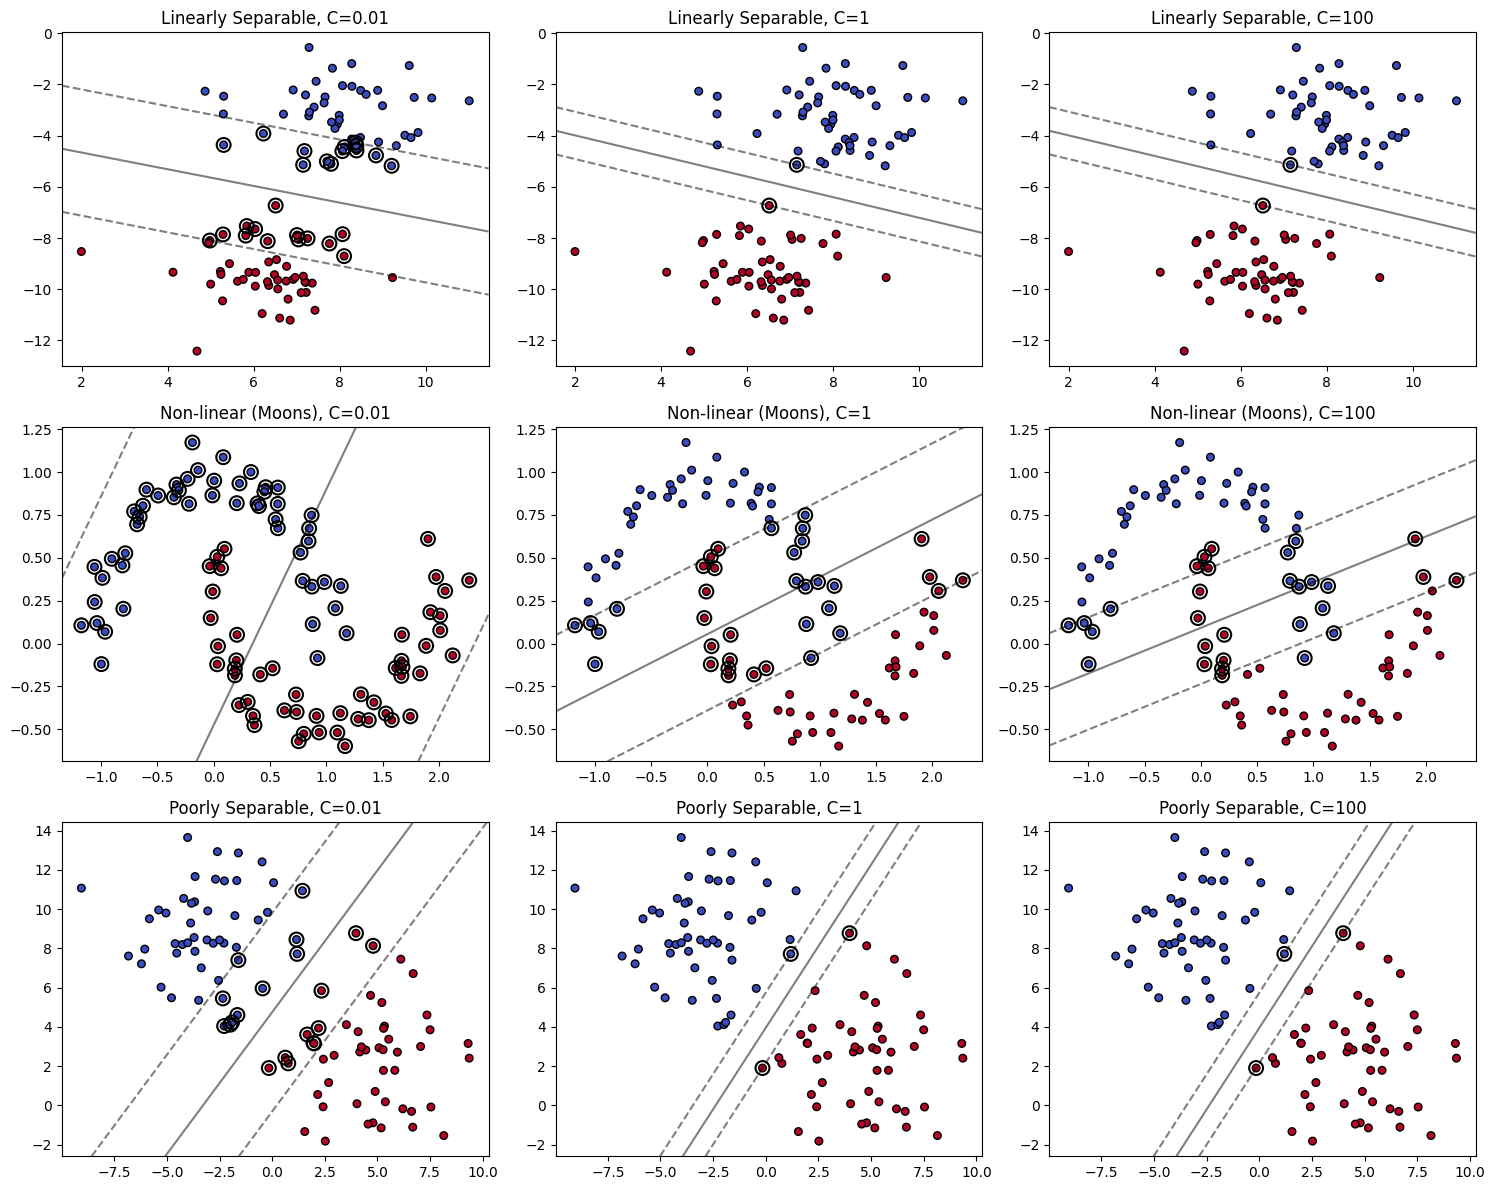

Построение квадратичного SVM...


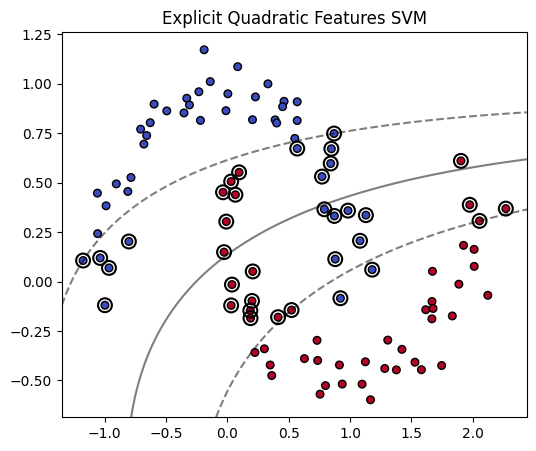

Готово!


In [27]:
# 1. Магия для отображения графиков (ОБЯЗАТЕЛЬНО)
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from cvxopt import matrix, solvers
from sklearn.datasets import make_blobs, make_moons

# Отключаем лишний вывод солвера
solvers.options['show_progress'] = False

# --- Определяем классы и функции ---

class PrimalSVM:
    def __init__(self, C=1.0):
        self.C = C
        self.w = None
        self.b = None
        
    def fit(self, X, y):
        y = y.astype(float).reshape(-1, 1)
        N, d = X.shape
        
        # P: диагональная, 1 для w, 0 для xi и b
        P_diag = np.zeros(d + N + 1)
        P_diag[:d] = 1.0 
        P = matrix(np.diag(P_diag))
        
        # q: C * sum(xi)
        q_vec = np.zeros(d + N + 1)
        q_vec[d:d+N] = self.C
        q = matrix(q_vec)
        
        # G: ограничения
        G_w_1 = -y * X
        G_xi_1 = -np.eye(N)
        G_b_1 = -y
        
        G_w_2 = np.zeros((N, d))
        G_xi_2 = -np.eye(N)
        G_b_2 = np.zeros((N, 1))
        
        block1 = np.hstack((G_w_1, G_xi_1, G_b_1))
        block2 = np.hstack((G_w_2, G_xi_2, G_b_2))
        G = matrix(np.vstack((block1, block2)))
        
        h = matrix(np.hstack((-np.ones(N), np.zeros(N))))
        
        # Решение
        sol = solvers.qp(P, q, G, h)
        z = np.array(sol['x']).flatten()
        
        self.w = z[:d]
        self.b = z[-1]
        return self

    def decision_function(self, X):
        return np.dot(X, self.w) + self.b

class KernelSVM_Explicit(PrimalSVM):
    def __init__(self, C=1.0, transform=None):
        super().__init__(C)
        self.transform = transform
        
    def fit(self, X, y):
        if self.transform:
            X_transformed = self.transform(X)
            super().fit(X_transformed, y)
        else:
            super().fit(X, y)
        return self
        
    def decision_function(self, X):
        if self.transform:
            return super().decision_function(self.transform(X))
        return super().decision_function(X)

def quadratic_feature_map(X):
    x1 = X[:, 0:1]
    x2 = X[:, 1:2]
    return np.hstack([x1, x2, x1**2, x2**2, x1*x2])

# ИСПРАВЛЕННАЯ функция рисования
def plot_svm_margin(model, X, y, ax=None, title=""):
    if ax is None:
        ax = plt.gca()
        
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=30, edgecolors='k')

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # Считаем Z для фона
    Z = model.decision_function(xy).reshape(XX.shape)

    # Рисуем линии уровня
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    
    # Выделяем опорные вектора (используем исходные X для проверки)
    dec_values = model.decision_function(X).flatten()
    support_mask = (y * dec_values) <= 1.001
    ax.scatter(X[support_mask, 0], X[support_mask, 1], s=100,
               linewidth=1.5, facecolors='none', edgecolors='k', label='Support Vectors')
    
    ax.set_title(title)

# --- ЗАПУСК ---
print("Генерация данных...")
# 1. Линейно разделимые
X1, y1 = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=1.2)
y1 = 2 * (y1 - 0.5) 

# 2. Нелинейные (Moons)
X2, y2 = make_moons(n_samples=100, noise=0.1, random_state=42)
y2 = 2 * (y2 - 0.5)

# 3. Плохо разделимые
X3, y3 = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=2.5)
y3 = 2 * (y3 - 0.5)

datasets = [(X1, y1, "Linearly Separable"), 
            (X2, y2, "Non-linear (Moons)"), 
            (X3, y3, "Poorly Separable")]

print("Обучение моделей и построение графиков...")
C_values = [0.01, 1, 100]
plt.figure(figsize=(15, 12))

plot_idx = 1
for X, y, name in datasets:
    for C in C_values:
        model = PrimalSVM(C=C)
        model.fit(X, y)
        
        ax = plt.subplot(3, 3, plot_idx)
        plot_svm_margin(model, X, y, ax=ax, title=f"{name}, C={C}")
        plot_idx += 1

plt.tight_layout()
plt.show()

print("Построение квадратичного SVM...")
# Отдельный график для Kernel SVM
model_kernel = KernelSVM_Explicit(C=1.0, transform=quadratic_feature_map)
model_kernel.fit(X2, y2)

plt.figure(figsize=(6, 5))
plot_svm_margin(model_kernel, X2, y2, title="Explicit Quadratic Features SVM")
plt.show()

print("Готово!")


# 3. Двойственный переход и Ядровой SVM

Задачу обучения линейного SVM, рассмотренную в предыдущем пункте принято называть _прямой_ оптимизационной задачей для SVM. Любая задача оптимизации с ограничениями имеет [_двойственную_ задачу Лагранжа](http://goo.gl/OujTPr), в которой оптимизируются _двойственные переменные_ (множители Лагранжа), соответствующие штрафу за нарушение ограничений, максимизируется нижняя оценка функционала прямой задачи. В случае задачи квадратичного программирования, решение двойственной задачи (значение оптимизируемого функционала) совпадает с оптимумом прямой задачи.

Подробнее можно почитать в [статье](./SMAIS11_SVM.pdf).

Двойственная задача для SVM имеет вид:
$$
\begin{gather}
    \sum_{n} \alpha_n - \frac{1}{2}\sum_{n}\sum_{n'} \alpha_{n}\alpha_{n'} y_{n}y_{n'} x_{n}^Tx_{n'} \to \max_{\alpha} \\
    \begin{aligned}
        \text{s.t. } \quad  
        & 0 \le \alpha_n \le C, \quad \forall n = 1, \dots, N \\
        & \sum_{n} \alpha_n y_n = 0
    \end{aligned}
\end{gather}
$$

Оптимизируется вектор из двойственных переменных $\alpha_n$, соответствующих объектам обучающей выборки. Объект $x_n$ является опорным, если $\alpha_n > 0$.

Предсказание вычисляется по следующему правилу:
$$\hat{y}(x) = \text{sign}\left(\sum_{n}\alpha_{n}y_{n}x^Tx_{n} + b\right).$$

Для предсказания необходимо оценить значение $b$. Известно, что для любого опорного объекта, который классифицируется безошибочно верно:
$$y_n = \sum_{n'}\alpha_{n}y_{n}x_{n}^Tx_{n'} + b,$$
значит для любого такого объекта:
$$b = y_n - \sum_{n'}\alpha_{n}y_{n}x_{n}^Tx_{n'}.$$

В случае наличия ошибок классификации обучающей выборки, предлагается усреднять значение $b$ по всем опорным векторам:
$$b = \frac{1}{N_\text{SV}}\sum_{n \in \text{SV}}\left(y_n - \sum_{n'}\alpha_{n}y_{n}x_{n}^Tx_{n'}\right).$$
Интуиция здесь такова, что суммарные ошибки в положительную сторону примерно равны суммарным ошибкам в отрицательную сторону.

Другой вариант — отказаться от параметра $b$ и работать с моделью $f(x) = w^Tx$, добавив к вектору $x$ константный признак.

#### Неявное преобразование признаков
Отметим, что двойственная задача SVM содержит вектора признаков исключительно в виде скалярного произведения $x^Tx'$. Эта особенность позволяет производить неявное преобразование признакового пространства. Вместо вычисления функции $\phi(\boldsymbol x)$, которая может отображать исходные признаки в вектора очень большой размерности, будем вычислять скалярное произведение $k(\boldsymbol x, \boldsymbol x') = \phi(\boldsymbol x)^T\phi(\boldsymbol x')$ называемое _ядром_. 

#### Задание
  1. Реализуйте процедуру обучения ядрового SVM, используя QP-солвер.
  2. Протестируйте на случайных двумерных выборках ядровой SVM. Покажите на плоскости строящиеся разделяющие поверхности, линии уровня, ограничивающие коридор $f(\boldsymbol x) = \pm 1$. Выделите опорные вектора точками другой формы или большего размера. Попробуйте следующие ядровые функции:
    - линейная: $k(x, x') = x^Tx'$
    - полиномиальная: $k(x, x') = (x^Tx' + 1)^p$ с различными степенями $p = 2,3,\dots$
    - Гауссовская-RBF: $k(x, x') = \exp(-\frac{1}{2\gamma}\|x - x'\|^2)$
  3. Как ведет себя SVM с полиномиальным ядром в зависимости от параметров $C$ и степени ядра $p$?
  4. Как ведет себя SVM с RBF-ядром в зависимости от параметров $C$ и $\gamma$? Поварьируйте параметры $C$ и $\gamma$ по логарифмической сетке. Какие значения параметров ведут к переобучению, а какие — к слишком грубой модели?

In [31]:
import numpy as np
from cvxopt import matrix, solvers
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons

# Отключаем лишний вывод солвера
solvers.options['show_progress'] = False

class PrimalSVM:
    def __init__(self, C=1.0):
        self.C = C
        self.w = None
        self.b = None
        
    def fit(self, X, y):
        # Преобразуем y в float, на всякий случай
        y = y.astype(float).reshape(-1, 1)
        N, d = X.shape
        
        # Нам нужно найти вектор z = [w (d шт), xi (N шт), b (1 шт)]
        # Всего переменных: d + N + 1
        
        # 1. Матрица P (квадратичная часть)
        # Минимизируем 0.5 * ||w||^2. 
        # Значит P — диагональная, где 1 стоит только на позициях w.
        # Для xi и b стоят нули.
        P_diag = np.zeros(d + N + 1)
        P_diag[:d] = 1.0 
        P = matrix(np.diag(P_diag))
        
        # 2. Вектор q (линейная часть)
        # Минимизируем C * sum(xi).
        # Для w и b стоят нули, для xi стоит C.
        q_vec = np.zeros(d + N + 1)
        q_vec[d:d+N] = self.C
        q = matrix(q_vec)
        
        # 3. Ограничения Gx <= h
        # У нас два типа ограничений:
        # а) y_i(w^T x_i + b) >= 1 - xi  =>  -y_i x_i w - xi - y_i b <= -1
        # б) xi >= 0                     =>  -xi <= 0
        
        # Формируем блок для (а):
        # Коэффициенты при w: -y * X
        G_w_1 = -y * X
        # Коэффициенты при xi: -I (единичная матрица)
        G_xi_1 = -np.eye(N)
        # Коэффициенты при b: -y
        G_b_1 = -y
        
        # Формируем блок для (б):
        # Коэффициенты при w: 0
        G_w_2 = np.zeros((N, d))
        # Коэффициенты при xi: -I
        G_xi_2 = -np.eye(N)
        # Коэффициенты при b: 0
        G_b_2 = np.zeros((N, 1))
        
        # Собираем все вместе в матрицу G
        # Строк будет 2*N, столбцов d+N+1
        block1 = np.hstack((G_w_1, G_xi_1, G_b_1))
        block2 = np.hstack((G_w_2, G_xi_2, G_b_2))
        G = matrix(np.vstack((block1, block2)))
        
        # Вектор h
        # Для (а) справа -1, для (б) справа 0
        h_vec = np.hstack((-np.ones(N), np.zeros(N)))
        h = matrix(h_vec)
        
        # 4. Решение
        sol = solvers.qp(P, q, G, h)
        z = np.array(sol['x']).flatten()
        
        # Извлекаем параметры
        self.w = z[:d]
        self.xi = z[d:d+N]
        self.b = z[-1]
        
        return self

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)
    
    def decision_function(self, X):
        return np.dot(X, self.w) + self.b

Kernel: poly, C: 1.0 -> Found 54 SVs
Kernel: poly, C: 1.0 -> Found 27 SVs
Kernel: poly, C: 1.0 -> Found 15 SVs
Kernel: poly, C: 1.0 -> Found 10 SVs


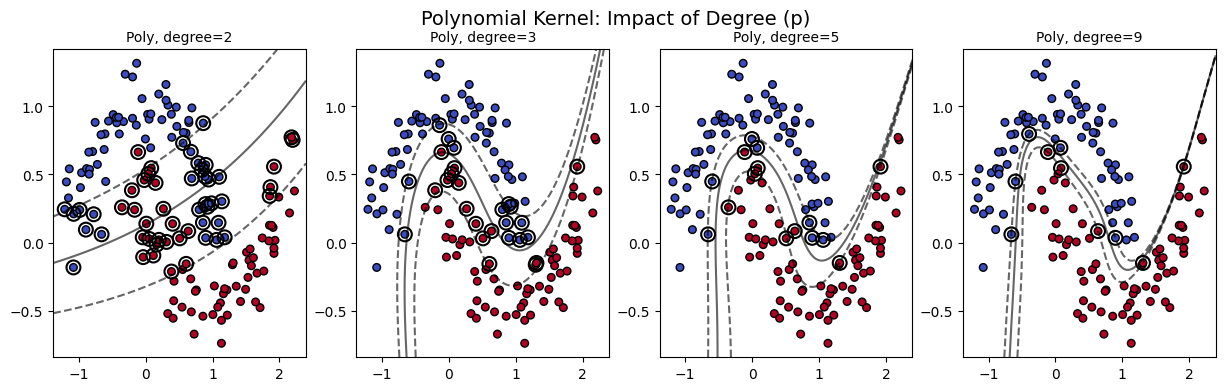

Kernel: rbf, C: 1.0 -> Found 150 SVs
Kernel: rbf, C: 1.0 -> Found 33 SVs
Kernel: rbf, C: 1.0 -> Found 44 SVs
Kernel: rbf, C: 1.0 -> Found 122 SVs


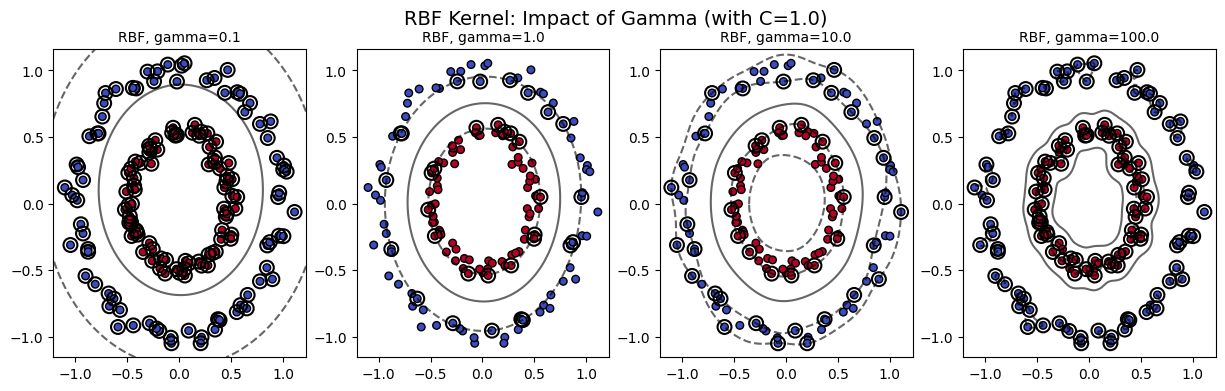

Kernel: rbf, C: 0.01 -> Found 150 SVs
Kernel: rbf, C: 1.0 -> Found 42 SVs
Kernel: rbf, C: 100.0 -> Found 10 SVs
Kernel: rbf, C: 10000.0 -> Found 11 SVs


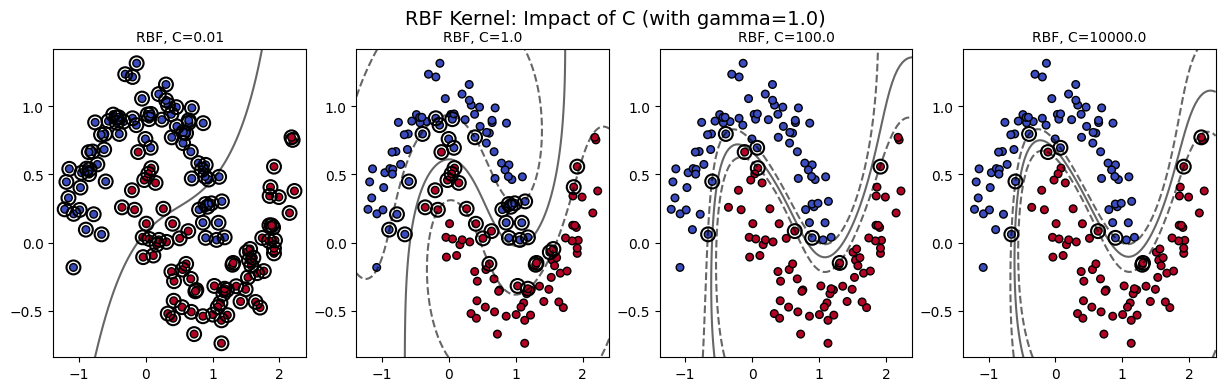

In [32]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers
from sklearn.datasets import make_blobs, make_moons, make_circles

# Отключаем вывод логов солвера
solvers.options['show_progress'] = False

# --- 1. Функции Ядер ---
def linear_kernel(X1, X2):
    return np.dot(X1, X2.T)

def polynomial_kernel(X1, X2, degree=3):
    return (np.dot(X1, X2.T) + 1) ** degree

def rbf_kernel(X1, X2, gamma=1.0):
    # Вычисляем ||x - y||^2 как ||x||^2 + ||y||^2 - 2<x, y>
    # X1: (N1, d), X2: (N2, d)
    sq_norm1 = np.sum(X1**2, axis=1).reshape(-1, 1)
    sq_norm2 = np.sum(X2**2, axis=1).reshape(1, -1)
    # Используем broadcast для сложения
    dist_sq = sq_norm1 + sq_norm2 - 2 * np.dot(X1, X2.T)
    return np.exp(-gamma * dist_sq)

# --- 2. Класс DualSVM ---
class DualSVM:
    def __init__(self, C=1.0, kernel='linear', degree=3, gamma=1.0):
        self.C = C
        self.kernel_type = kernel
        self.degree = degree
        self.gamma = gamma
        self.alpha = None
        self.b = 0.0
        self.support_vectors = None
        self.support_labels = None
        self.support_alpha = None

    def _get_kernel(self, X1, X2):
        if self.kernel_type == 'linear':
            return linear_kernel(X1, X2)
        elif self.kernel_type == 'poly':
            return polynomial_kernel(X1, X2, degree=self.degree)
        elif self.kernel_type == 'rbf':
            return rbf_kernel(X1, X2, gamma=self.gamma)
        else:
            raise ValueError(f"Unknown kernel: {self.kernel_type}")

    def fit(self, X, y):
        N = X.shape[0]
        y = y.astype(float)
        
        # 1. Матрица Грама (ядро)
        K = self._get_kernel(X, X)
        
        # 2. Формируем матрицы для QP: 1/2 x^T P x + q^T x
        # P_ij = y_i * y_j * K(x_i, x_j)
        P = matrix(np.outer(y, y) * K)
        # Добавляем крошечное число к диагонали для стабильности (regularization)
        P = P + matrix(np.eye(N) * 1e-7)
        
        # q = вектор из -1
        q = matrix(-np.ones(N))
        
        # 3. Ограничения неравенства: Gx <= h
        # 0 <= alpha_i <= C
        # -alpha_i <= 0  (G1 = -I, h1 = 0)
        # alpha_i <= C   (G2 = I,  h2 = C)
        G = matrix(np.vstack((-np.eye(N), np.eye(N))))
        h = matrix(np.hstack((np.zeros(N), np.ones(N) * self.C)))
        
        # 4. Ограничение равенства: Ax = b
        # sum(alpha_i * y_i) = 0
        A = matrix(y.reshape(1, -1))
        b_eq = matrix(np.zeros(1))
        
        # 5. Решаем задачу
        try:
            sol = solvers.qp(P, q, G, h, A, b_eq)
            alphas = np.array(sol['x']).flatten()
        except ValueError as e:
            print(f"Optimization failed with C={self.C}, kernel={self.kernel_type}: {e}")
            alphas = np.zeros(N)

        # 6. Выбираем опорные вектора
        # alpha > 0 (берем порог 1e-5 для отсечения нулей)
        sv_mask = alphas > 1e-5
        
        self.support_alpha = alphas[sv_mask]
        self.support_vectors = X[sv_mask]
        self.support_labels = y[sv_mask]
        
        print(f"Kernel: {self.kernel_type}, C: {self.C} -> Found {len(self.support_vectors)} SVs")
        
        # 7. Восстанавливаем сдвиг b
        # b = mean( y_k - sum(alpha_i * y_i * K(x_i, x_k)) ) для всех SV
        if len(self.support_vectors) > 0:
            # Считаем K между всеми SV и ими же
            K_sv = self._get_kernel(self.support_vectors, self.support_vectors)
            # Вектор предсказаний без b для каждого SV
            # (N_sv, N_sv) dot (N_sv,) -> (N_sv,)
            pred_term = np.dot(K_sv, self.support_alpha * self.support_labels)
            self.b = np.mean(self.support_labels - pred_term)
        else:
            self.b = 0.0
            
        return self

    def decision_function(self, X):
        if self.support_vectors is None or len(self.support_vectors) == 0:
            return np.zeros(X.shape[0])
        
        # Считаем ядро между SV и новыми точками X
        # K_cross: (N_sv, N_new)
        K_cross = self._get_kernel(self.support_vectors, X)
        
        # Предсказание = (alpha * y) @ K_cross + b
        # (N_sv,) @ (N_sv, N_new) -> (N_new,)
        return np.dot(self.support_alpha * self.support_labels, K_cross) + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X))

# --- 3. Функция отрисовки ---
def plot_kernel_svm(model, X, y, ax=None, title=""):
    if ax is None:
        ax = plt.gca()
        
    # Рисуем точки
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=30, edgecolors='k')

    # Рисуем SV (опорные вектора)
    if model.support_vectors is not None:
        ax.scatter(model.support_vectors[:, 0], model.support_vectors[:, 1],
                   s=100, linewidth=1.5, facecolors='none', edgecolors='k', label='SV')

    # Сетка
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # Линии уровня
    Z = model.decision_function(xy).reshape(XX.shape)
    
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.6,
               linestyles=['--', '-', '--'])
    
    ax.set_title(title, fontsize=10)

# --- 4. Эксперименты ---

# Генерация данных
X_moons, y_moons = make_moons(n_samples=150, noise=0.15, random_state=42)
y_moons = 2*(y_moons - 0.5)

X_circ, y_circ = make_circles(n_samples=150, noise=0.05, factor=0.5, random_state=42)
y_circ = 2*(y_circ - 0.5)

# --- Тест 1: Полиномиальное ядро (влияние степени) ---
plt.figure(figsize=(15, 4))
plt.suptitle("Polynomial Kernel: Impact of Degree (p)", fontsize=14)
degrees = [2, 3, 5, 9]

for i, p in enumerate(degrees):
    ax = plt.subplot(1, 4, i+1)
    model = DualSVM(C=1.0, kernel='poly', degree=p)
    model.fit(X_moons, y_moons)
    plot_kernel_svm(model, X_moons, y_moons, ax=ax, title=f"Poly, degree={p}")
plt.show()

# --- Тест 2: RBF ядро (влияние Gamma) ---
plt.figure(figsize=(15, 4))
plt.suptitle("RBF Kernel: Impact of Gamma (with C=1.0)", fontsize=14)
gammas = [0.1, 1.0, 10.0, 100.0]

for i, g in enumerate(gammas):
    ax = plt.subplot(1, 4, i+1)
    model = DualSVM(C=1.0, kernel='rbf', gamma=g)
    model.fit(X_circ, y_circ)
    plot_kernel_svm(model, X_circ, y_circ, ax=ax, title=f"RBF, gamma={g}")
plt.show()

# --- Тест 3: RBF ядро (влияние C при фиксированной Gamma) ---
plt.figure(figsize=(15, 4))
plt.suptitle("RBF Kernel: Impact of C (with gamma=1.0)", fontsize=14)
cs = [0.01, 1.0, 100.0, 10000.0]

for i, c_val in enumerate(cs):
    ax = plt.subplot(1, 4, i+1)
    model = DualSVM(C=c_val, kernel='rbf', gamma=1.0)
    model.fit(X_moons, y_moons)
    plot_kernel_svm(model, X_moons, y_moons, ax=ax, title=f"RBF, C={c_val}")
plt.show()

### Полиномиальное ядро (ряд 1)
Вопрос: Как ведет себя SVM в зависимости от степени ядра $p$?
 - При малых $p$ (2, 3): Граница разделения плавная, похожа на дуги парабол или кубических кривых. Хорошо обобщает данные "лун".
 - При больших $p$ (5, 9): Граница становится очень сложной и извилистой. Появляются замкнутые "островки" вокруг отдельных точек. Это признак переобучения. Модель пытается описать данные полиномом высокой степени, что приводит к осцилляциям.


### Вопрос:
Как ведет себя RBF в зависимости от $\gamma$?
- Параметр $\gamma$ (gamma) определяет "дальность влияния" одного примера. Чем больше $\gamma$, тем быстрее затухает колокол Гаусса.
- Малое $\gamma$ (0.1): Очень широкие "колокола". Граница почти линейная или плавно изогнутая. Может быть недообучение, если данные сложны.
- Среднее $\gamma$ (1.0 - 10.0): Оптимальный баланс. Хорошо разделяет концентрические круги.
- Большое $\gamma$ (100.0): Каждый опорный вектор создает вокруг себя крошечный "островок". Граница распадается на пятна вокруг точек. Это жесткое переобучение (метод "ближайшего соседа").

  RBF ядро: Влияние $C$ (ряд 3)Вопрос:

  Взаимодействие $C$ и RBF.
  - Малое $C$ (0.01): Очень широкая полоса (Soft Margin). Модель игнорирует много ошибок, граница очень сглаженная (почти прямая линия, даже с ядром).
  - Большое $C$ (10000): Модель старается правильно классифицировать каждую, даже самую сложную точку. Граница становится изрезанной, чтобы обойти каждый шумовой объект.
  -
    ## Вывод для отчета:
    - Для переобучения характерны: очень большие $C$, очень большие $\gamma$ (RBF) или очень высокие степени полинома $p$. Граница становится "рваной" и фрагментированной.
    - Для слишком грубой модели (недообучения) характерны: очень малые $C$ или слишком малые $\gamma$. Граница слишком простая и не улавливает структуру данных.

# Примеры

Настройка вывода графиков [`Maplotlib`](http://matplotlib.org/) и импорт функций из модуля [`pylab`](http://wiki.scipy.org/PyLab).

In [22]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


C:\Anaconda3\lib\site-packages\IPython\core\magics\pylab.py:160: UserWarning: pylab import has clobbered these variables: ['matrix']
`%matplotlib` prevents importing * from pylab and numpy
  "\n`%matplotlib` prevents importing * from pylab and numpy"


## Визуальное решение задачи квадратичного программирования

На следующем рисунке наглядно показано решение задачи QP из задания 1. Оптимизируемая функция $f(\boldsymbol x)$ показана линиями уровня, область значений недопустимых ограничениями окрашена в серый цвет.

C:\Anaconda3\lib\site-packages\matplotlib\contour.py:902: UserWarning: linewidths is ignored by contourf
  warnings.warn('linewidths is ignored by contourf')


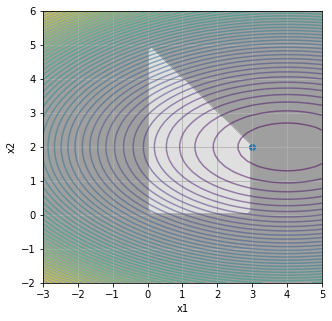

In [33]:
x1 = linspace(-3, 5, 50)
x2 = linspace(-2, 6, 50)
xx1, xx2 = meshgrid(x1, x2)

f = -8*xx1 - 16*xx2 + xx1**2 + 4*xx2**2
constr1 = (xx1 + xx2 <= 5)
constr2 = (0 <= xx1) & (xx1 <= 3)
constr3 = (xx2 >= 0)

figure(figsize=(5, 5))
grid(True)
xlabel('x1')
ylabel('x2')

contour(x1, x2, f, 50, alpha=0.5)
contourf(x1, x2, constr1 & constr2 & constr3, 1, alpha=0.5, linewidths=4, cmap='gray')
_ = scatter([3], [2])

In [26]:
np.array([True, False, False]) & np.array([True, False, True])

array([ True, False, False])

In [27]:
np.logical_and(np.array([True, False, False]), np.array([True, False, True]))

array([ True, False, False])

## Установка и использование `CvxOpt`

Библиотека [`cvxopt`](http://cvxopt.org/) может быть установлена как обычный python-пакет:

In [5]:
!pip install --upgrade --user cvxopt

  Using cached https://files.pythonhosted.org/packages/16/a0/0d090735e2639a74d6628831e02cc59284e3a3a4f5910f496fc6e435b645/cvxopt-1.2.5-cp36-cp36m-win_amd64.whl
  Using cached https://files.pythonhosted.org/packages/56/39/537cb3e4e93f1ac5085dc3b3a43cfd99d0af9b29c44fcaa99490f526b611/mkl-2019.0-py2.py3-none-win_amd64.whl


Нас будет интересовать функция [`cvxopt.solvers.qp()`](http://cvxopt.org/examples/tutorial/qp.html):

In [6]:
from cvxopt import solvers
?solvers.qp

## Пример работы с cvxopt

In [4]:
from cvxopt import matrix

A = matrix([1.0, 2.0, 3.0, 4.0, 5.0, 6.0], (2,3))
print(A)
print(A.size)

[ 1.00e+00  3.00e+00  5.00e+00]
[ 2.00e+00  4.00e+00  6.00e+00]

(2, 3)


In [6]:
G = matrix([[-1.0,0.0,-1.0,2.0,3.0],
            [0.0,-1.0,-3.0,5.0,4.0]])
print(G, G.size)

[-1.00e+00  0.00e+00]
[ 0.00e+00 -1.00e+00]
[-1.00e+00 -3.00e+00]
[ 2.00e+00  5.00e+00]
[ 3.00e+00  4.00e+00]
 (5, 2)


In [13]:
from cvxopt import solvers

# Define QP parameters (directly)
P = matrix([[1.0,0.0],[0.0,0.0]])
q = matrix([3.0,4.0])
G = matrix([[-1.0,0.0,-1.0,2.0,3.0],[0.0,-1.0,-3.0,5.0,4.0]])
h = matrix([0.0,0.0,-15.0,100.0,80.0])
# Define QP parameters (with NumPy)
P = matrix(numpy.diag([1,0]), tc='d')
q = matrix(numpy.array([3,4]), tc='d')
G = matrix(numpy.array([[-1,0],[0,-1],[-1,-3],[2,5],[3,4]]), tc='d')
h = matrix(numpy.array([0,0,-15,100,80]), tc='d')
# Construct the QP, invoke solver
sol = solvers.qp(P,q,G,h)
# Extract optimal value and solution
print(sol['x']) # [7.13e-07, 5.00e+00]
print(sol['primal objective']) # 20.0000061731

     pcost       dcost       gap    pres   dres
 0:  1.0780e+02 -7.6366e+02  9e+02  4e-17  4e+01
 1:  9.3245e+01  9.7637e+00  8e+01  8e-17  3e+00
 2:  6.7311e+01  3.2553e+01  3e+01  8e-17  1e+00
 3:  2.6071e+01  1.5068e+01  1e+01  7e-17  7e-01
 4:  3.7092e+01  2.3152e+01  1e+01  1e-16  4e-01
 5:  2.5352e+01  1.8652e+01  7e+00  9e-17  4e-16
 6:  2.0062e+01  1.9974e+01  9e-02  7e-17  2e-16
 7:  2.0001e+01  2.0000e+01  9e-04  8e-17  2e-16
 8:  2.0000e+01  2.0000e+01  9e-06  1e-16  2e-16
Optimal solution found.
[ 7.13e-07]
[ 5.00e+00]

20.00000617311241


In [14]:
sol

{'x': <2x1 matrix, tc='d'>,
 'y': <0x1 matrix, tc='d'>,
 's': <5x1 matrix, tc='d'>,
 'z': <5x1 matrix, tc='d'>,
 'status': 'optimal',
 'gap': 8.788553731701274e-06,
 'relative gap': 4.3942774404993765e-07,
 'primal objective': 20.00000617311241,
 'dual objective': 19.99999738455868,
 'primal infeasibility': 1.1710307819972547e-16,
 'dual infeasibility': 1.9860273225978186e-16,
 'primal slack': 7.131816408857108e-07,
 'dual slack': 1.50695110360481e-08,
 'iterations': 8}

In [19]:
print(sol['x'])

[ 7.13e-07]
[ 5.00e+00]



Матрицы задач квадратичного программирования как правило разрежены, лучше использовать матричные операции над разреженными матрицами при реализации SVM.
[Разреженные и плотные матрицы](http://abel.ee.ucla.edu/cvxopt/userguide/matrices.html)

## Генерация случайной выборки для задачи классификации

В `SciKit-Learn` есть функция генерации случайных выборок для классификации [`sklearn.datasets.make_classification()`](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html). Для того чтобы выборки не менялись при перезапуске ноутбука, используйте параметр `random_state`.

In [7]:
from sklearn.datasets import make_classification

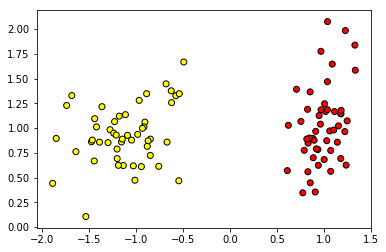

In [10]:
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=1)
scatter(X[:, 0], X[:, 1], c=y, cmap='autumn', edgecolor='black')

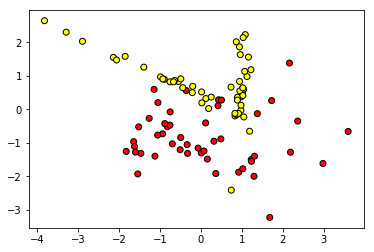

In [11]:
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, n_clusters_per_class=2, random_state=2)
scatter(X[:, 0], X[:, 1], c=y, cmap='autumn', edgecolor='black')

## Визуализация решающего правила

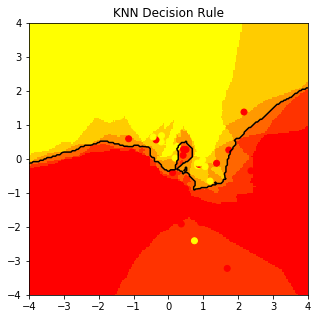

In [12]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X, y)

figure(figsize=(5, 5))
scatter(X[:, 0], X[:, 1], c=y, cmap='autumn')

xvals = linspace(-4, 4, 200)
yvals = linspace(-4, 4, 200)

xx, yy = np.meshgrid(xvals, yvals)
zz = np.reshape(model.predict_proba(c_[xx.ravel(), yy.ravel()])[:, 1], xx.shape)

# Цветной фон, соответствующий значению решающего правила
pcolormesh(xx, yy, zz, cmap='autumn', zorder=0)

# Линия уровня, соответствующая значению 0.5
contour(xx, yy, zz, levels=(0.5,), colors='k', linewidths=1.5, zorder=1)

xlim([-4, 4])
ylim([-4, 4])
_ = title('KNN Decision Rule')

## Реализация собственной модели для SciKit-Learn

В заданиях 2 и 3 требуется самостоятельно реализовать алгоритм обучения классификатора. Для того чтобы ваш алгоритм можно было использовать различными компонентами библиотеки SciKit-Learn (оценка качества, подбор параметров, композиции и т.д.) нужно всего лишь [реализовать интерфейс `BaseEstimator`](http://scikit-learn.org/stable/developers/#estimators).

In [46]:
import numpy as np
from cvxopt import matrix, solvers
from sklearn.base import BaseEstimator

# Отключаем вывод логов солвера
solvers.options['show_progress'] = False

class LinearSVM(BaseEstimator):
    def __init__(self, C=1.0, transform=None):
        self.C = C
        self.transform = transform
        self.weights_ = None
        self.bias_ = None
        
    def fit(self, X, y):
        """
        Функция обучения модели.
        """
        # 1. Применяем преобразование признаков, если оно задано
        if self.transform is not None:
            X_feat = self.transform(X)
        else:
            X_feat = X
            
        # Приводим y к правильному размеру
        y = y.astype(float).reshape(-1, 1)
        N, d = X_feat.shape
        
        # Переменные оптимизации z = [w (d), xi (N), b (1)]
        # Всего переменных: d + N + 1
        
        # Матрица P (квадратичная часть): минимизируем 0.5 * ||w||^2
        P_diag = np.zeros(d + N + 1)
        P_diag[:d] = 1.0 
        P = matrix(np.diag(P_diag))
        
        # Вектор q (линейная часть): минимизируем C * sum(xi)
        q_vec = np.zeros(d + N + 1)
        q_vec[d:d+N] = self.C
        q = matrix(q_vec)
        
        # Ограничения Gx <= h
        # 1) y_i(w^T x_i + b) >= 1 - xi  ->  -y_i x_i w - xi - y_i b <= -1
        # 2) xi >= 0                     ->  -xi <= 0
        
        # Блок 1 (основное ограничение)
        G_w_1 = -y * X_feat
        G_xi_1 = -np.eye(N)
        G_b_1 = -y
        
        # Блок 2 (неотрицательность слэков)
        G_w_2 = np.zeros((N, d))
        G_xi_2 = -np.eye(N)
        G_b_2 = np.zeros((N, 1))
        
        # Сборка G
        block1 = np.hstack((G_w_1, G_xi_1, G_b_1))
        block2 = np.hstack((G_w_2, G_xi_2, G_b_2))
        G = matrix(np.vstack((block1, block2)))
        
        # Сборка h
        h = matrix(np.hstack((-np.ones(N), np.zeros(N))))
        
        # Решение задачи
        sol = solvers.qp(P, q, G, h)
        z = np.array(sol['x']).flatten()
        
        # Сохранение весов и сдвига
        self.weights_ = z[:d]
        self.bias_ = z[-1]
        
        return self
        
    def predict_proba(self, X):
        # Если было преобразование при обучении, применяем его и тут
        if self.transform is not None:
            X_feat = self.transform(X)
        else:
            X_feat = X
        # Возвращаем "отступ" (расстояние до гиперплоскости)
        return (np.dot(X_feat, self.weights_) + self.bias_).flatten()
            
    def predict(self, X):
        return np.sign(self.predict_proba(X))

In [47]:
def linear_kernel(X1, X2):
    return np.dot(X1, X2.T)

def polynomial_kernel(X1, X2, degree=3):
    return (np.dot(X1, X2.T) + 1) ** degree

def rbf_kernel(X1, X2, gamma=1.0):
    # Эффективный расчет ||x - y||^2
    sq_norm1 = np.sum(X1**2, axis=1).reshape(-1, 1)
    sq_norm2 = np.sum(X2**2, axis=1).reshape(1, -1)
    dist_sq = sq_norm1 + sq_norm2 - 2 * np.dot(X1, X2.T)
    return np.exp(-gamma * dist_sq)

In [48]:
def linear_kernel(X1, X2):
    return np.dot(X1, X2.T)

def polynomial_kernel(X1, X2, degree=3):
    return (np.dot(X1, X2.T) + 1) ** degree

def rbf_kernel(X1, X2, gamma=1.0):
    # Эффективный расчет ||x - y||^2
    sq_norm1 = np.sum(X1**2, axis=1).reshape(-1, 1)
    sq_norm2 = np.sum(X2**2, axis=1).reshape(1, -1)
    dist_sq = sq_norm1 + sq_norm2 - 2 * np.dot(X1, X2.T)
    return np.exp(-gamma * dist_sq)

In [49]:
class DualSVM(BaseEstimator):
    def __init__(self, C=1.0, kernel=None):
        self.C = C
        self.kernel = kernel
        self.alpha_ = None
        self.bias_ = 0
        self.support_vectors_ = None
        self.support_labels_ = None
        self.support_alpha_ = None
        
    def fit(self, X, y):
        """
        Функция обучения модели.
        """
        self.N = X.shape[0]
        self.dim = X.shape[1]
        y = y.astype(float)
        
        # Если ядро не передано, используем линейное по умолчанию
        if self.kernel is None:
            # Локальная функция, если kernel не задан
            calc_kernel = lambda x1, x2: np.dot(x1, x2.T)
        else:
            calc_kernel = self.kernel

        # 1. Вычисляем матрицу Грама
        K = calc_kernel(X, X)
        
        # 2. Формируем матрицы для QP: min 1/2 alpha^T P alpha + q^T alpha
        # P_ij = y_i * y_j * K(x_i, x_j)
        P = matrix(np.outer(y, y) * K)
        # Добавляем малую регуляризацию для стабильности солвера
        P = P + matrix(np.eye(self.N) * 1e-7)
        
        # q = вектор из -1 (т.к. мы максимизируем сумму alpha, или минимизируем -сумму)
        q = matrix(-np.ones(self.N))
        
        # 3. Ограничения неравенства: 0 <= alpha <= C
        # а) -alpha <= 0
        # б) alpha <= C
        G = matrix(np.vstack((-np.eye(self.N), np.eye(self.N))))
        h = matrix(np.hstack((np.zeros(self.N), np.ones(self.N) * self.C)))
        
        # 4. Ограничение равенства: sum(alpha * y) = 0
        A = matrix(y.reshape(1, -1))
        b_eq = matrix(np.zeros(1))
        
        # Решение
        sol = solvers.qp(P, q, G, h, A, b_eq)
        self.alpha_ = np.array(sol['x']).flatten()
        
        # Отбор опорных векторов (alpha > 0)
        sv_mask = self.alpha_ > 1e-5
        self.support_alpha_ = self.alpha_[sv_mask]
        self.support_vectors_ = X[sv_mask]
        self.support_labels_ = y[sv_mask]
        
        # Расчет bias (сдвига)
        if len(self.support_vectors_) > 0:
            # Вычисляем K(SV, SV)
            K_sv = calc_kernel(self.support_vectors_, self.support_vectors_)
            # Предсказание без bias: sum(alpha * y * K)
            y_pred_no_bias = np.dot(K_sv, self.support_alpha_ * self.support_labels_)
            # b = mean(y_true - y_pred_no_bias)
            self.bias_ = np.mean(self.support_labels_ - y_pred_no_bias)
        else:
            self.bias_ = 0.0
            
        return self
        
    def predict_proba(self, X):
        # Возвращает значение решающей функции (расстояние до границы)
        if self.support_vectors_ is None or len(self.support_vectors_) == 0:
            return np.zeros(X.shape[0])
            
        # Определяем функцию ядра
        if self.kernel is None:
             calc_kernel = lambda x1, x2: np.dot(x1, x2.T)
        else:
            calc_kernel = self.kernel
            
        # Считаем ядро между опорными векторами и новыми данными
        K_cross = calc_kernel(self.support_vectors_, X)
        
        # decision = sum(alpha_i * y_i * K(sv_i, x)) + b
        # (N_sv,) @ (N_sv, N_new) -> (N_new,)
        decision = np.dot(self.support_alpha_ * self.support_labels_, K_cross) + self.bias_
        return decision.flatten()
            
    def predict(self, X):
        return np.sign(self.predict_proba(X))

In [50]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from functools import partial

# 1. Генерируем данные (например, "луны")
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)
y = 2 * (y - 0.5)  # Переводим метки из [0, 1] в [-1, 1] для нашего SVM!

# 2. Разбиваем на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Создаем модель
# Важно: используем partial, чтобы "заморозить" параметр gamma для ядра
my_rbf_kernel = partial(rbf_kernel, gamma=1.0)
clf = DualSVM(C=1.0, kernel=my_rbf_kernel)

# 4. Обучаем
print("Обучение модели...")
clf.fit(X_train, y_train)

# 5. Предсказываем
y_pred = clf.predict(X_test)

# 6. Оцениваем качество
acc = accuracy_score(y_test, y_pred)
print(f"Точность (Accuracy): {acc:.2f}")
print(f"Количество опорных векторов: {len(clf.support_vectors_)}")

Обучение модели...
Точность (Accuracy): 0.97
Количество опорных векторов: 43
